# Causal Directional Graph-Spectral Hyperbolic Attention (CD-GSHA)

### A Causality-First Multi-Modal Architecture for Commodity Futures Direction Prediction

---

## Abstract

We propose **CD-GSHA**, an architecture for next-day direction prediction on commodity futures that integrates a novel **causal directional graph** with hyperbolic-Euclidean hybrid attention. The contribution is a rethinking of how causality is enforced in graph-based temporal models.

Existing graph models for temporal data — including the standard Chebyshev spectral convolution of Defferrard et al. (2016) and graph attention networks (Veličković et al., 2018) — use **symmetric** adjacency matrices on the temporal graph. This means information at day $i$ can flow to day $j$ regardless of which is earlier. For financial time-series this is a structural violation of causality, since a representation at day $i$ may then incorporate signal from day $j > i$. The standard fix is to add a causal self-attention block after the graph convolution, but this is a patch on top of an a-causal operator, not a causality-respecting graph operator.

CD-GSHA replaces the symmetric news graph with a **directed acyclic graph** in which all edges flow strictly forward in time: $A_{ij} > 0$ only when $j \le i$. The graph has both semantic edges (between thematically similar news days) and temporal-prior edges (always-on with exponential decay), but every edge is oriented past → present. We then construct a **random-walk-normalized causal Laplacian** $\hat{\mathbf{L}}^{\text{dir}} = \mathbf{I} - \mathbf{D}_{\text{out}}^{-1}\mathbf{A}$ — which is appropriate for directed graphs since the symmetric normalization $\mathbf{D}^{-1/2}\mathbf{A}\mathbf{D}^{-1/2}$ is undefined when $\mathbf{A} \neq \mathbf{A}^\top$ — and apply Chebyshev polynomials $T_k(\hat{\mathbf{L}}^{\text{dir}})$ to it. Because the underlying operator is lower-triangular, every power $T_k(\hat{\mathbf{L}}^{\text{dir}})$ is also lower-triangular, so the spectral convolution **inherits** causality from the graph structure rather than being patched afterward.

This eliminates the redundant causal self-attention pass on the news side. The price branch still uses a causal LSTM + causal self-attention, since LSTM hidden states do not have an underlying graph. Cross-modal fusion uses a hybrid hyperbolic-Euclidean attention with the directional spectral output as keys and the price context as query.

---


## 1. Problem Setup

At trading day $t$ we predict
$$y_{t+1} = \mathbf{1}[P_{t+1} > P_t] \in \{0, 1\}$$
from a length-$T$ lookback window of three tensors:

- **Price features** $\mathbf{X} \in \mathbb{R}^{T \times d_x}$, where $d_x = 19$ technical and calendar features
- **News embeddings** $\mathbf{E} \in \mathbb{R}^{T \times d_e}$, where $d_e = 16$ is the FinBERT dimension; rows are zero on news-absent days
- **News mask** $\mathbf{m} \in \{0,1\}^T$, with $m_i = 1$ iff day $i$ has news

Setting: $T = 30$, dataset is approximately 4,000 trading days of U.S. wheat futures, news density is about 50%.


## 2. Mathematical Framework

### 2.1 The Causal Directional Graph (Novel)

The core innovation is a strictly directed temporal graph. For nodes $i, j \in \{1, \ldots, T\}$ representing days in the lookback window, we define edges:

**Causal semantic edges** — only past or current news flows into the present:
$$
A^{\text{sem}}_{ij} =
\begin{cases}
m_i \cdot m_j \cdot \sigma\!\big(\kappa\,(s_{ij} - \tau)\big) & \text{if } j \le i \\
0 & \text{if } j > i
\end{cases},
\qquad s_{ij} = \frac{\mathbf{e}_i^\top \mathbf{e}_j}{\|\mathbf{e}_i\|\,\|\mathbf{e}_j\|}
$$

The slope parameter $\kappa = 10$ produces a sharp soft-threshold at the learnable similarity cutoff $\tau$. The mask product $m_i m_j$ forces both endpoints of an edge to have news — semantic similarity between two zero embeddings is meaningless.

**Causal temporal-prior edges** — exponentially decaying past influence:
$$
A^{\text{tmp}}_{ij} =
\begin{cases}
\exp(-\gamma\,(i - j)) & \text{if } j \le i \\
0 & \text{if } j > i
\end{cases}
$$

These are always active, so the graph has full lower-triangular connectivity even on news-sparse windows. Without this, days with no news would be isolated nodes and the spectral convolution would have nothing to propagate to/from them.

**Self-loops** — day $i$'s own news has weight $\delta = \mathrm{softplus}(\theta_\delta) \ge 0$:
$$
A^{\text{self}}_{ii} = \delta, \qquad A^{\text{self}}_{ij} = 0 \text{ for } i \ne j
$$

Without this term day $i$'s own embedding cannot enter the spectral aggregation directly — it would only reach the output via the residual skip. Other days reach $i$ through $A_{ij}$, but $i$ itself does not, which is an asymmetry. A learnable self-loop weight restores this and lets the model decide how much to weight "today" against the history.

**Combined directed adjacency:**
$$
A_{ij} =
\begin{cases}
\delta & \text{if } j = i \\
\alpha_g\,A^{\text{sem}}_{ij} + \beta_g\,A^{\text{tmp}}_{ij} & \text{if } j < i \\
0 & \text{if } j > i
\end{cases}
$$

with $\{\tau, \gamma, \alpha_g, \beta_g, \delta\}$ all learnable. By construction $A$ is **lower-triangular** (including the diagonal), and strictly lower-triangular off the diagonal: $A_{ij} = 0$ whenever $j > i$.

---

### 2.2 Random-Walk-Normalized Causal Laplacian

For an undirected graph the symmetric Laplacian $\hat{\mathbf{L}} = \mathbf{D}^{-1/2}\mathbf{A}\mathbf{D}^{-1/2}$ is well-defined because $\mathbf{A} = \mathbf{A}^\top$. For a directed graph this expression is no longer symmetric and its spectral properties are not guaranteed to lie in $[-1, 1]$, which is required for the Chebyshev approximation to be numerically stable.

We instead use the **random-walk normalization** (Chung, 2005), which is the natural choice for directed graphs:

$$
\hat{\mathbf{L}}^{\text{dir}} = \mathbf{I} - \mathbf{D}_{\text{out}}^{-1}\mathbf{A}
$$

where $\mathbf{D}_{\text{out}}$ is the diagonal out-degree matrix:
$$
(D_{\text{out}})_{ii} = \max\!\Big(\sum_{j} A_{ij},\; \varepsilon\Big)
$$

Two important properties:

1. **Lower-triangularity is preserved.** $\mathbf{I}$ is diagonal and $\mathbf{D}_{\text{out}}^{-1}\mathbf{A}$ has the same sparsity pattern as $\mathbf{A}$ (lower-triangular including the diagonal). So $\hat{\mathbf{L}}^{\text{dir}}$ is lower-triangular. The diagonal entries of $\hat{\mathbf{L}}^{\text{dir}}$ are $1 - \delta / d^{\text{out}}_i$ rather than $1$, reflecting that the operator now uses some self-information.

2. **Spectrum is bounded.** Each row of $\mathbf{D}_{\text{out}}^{-1}\mathbf{A}$ sums to either 0 (isolated) or 1 (otherwise), so its eigenvalues lie in $[-1, 1]$, making $\hat{\mathbf{L}}^{\text{dir}}$'s eigenvalues lie in $[0, 2]$ — the same range as the symmetric normalized Laplacian.

---

### 2.3 Causal Chebyshev Spectral Convolution

The order-$K$ Chebyshev polynomial expansion of $\hat{\mathbf{L}}^{\text{dir}}$ is computed via the standard three-term recursion:

$$
T_0(\hat{\mathbf{L}}^{\text{dir}}) = \mathbf{I}, \qquad
T_1(\hat{\mathbf{L}}^{\text{dir}}) = \hat{\mathbf{L}}^{\text{dir}}, \qquad
T_{k+1} = 2\,\hat{\mathbf{L}}^{\text{dir}}\,T_k - T_{k-1}
$$

**Key fact (causality preservation).** The product of two lower-triangular matrices is lower-triangular. Since $\hat{\mathbf{L}}^{\text{dir}}$ is lower-triangular and $T_0 = \mathbf{I}$ is lower-triangular, by induction every $T_k$ is lower-triangular. So:

$$
\big[T_k(\hat{\mathbf{L}}^{\text{dir}})\,\mathbf{E}\big]_i \;=\; \sum_{j \le i} \big[T_k\big]_{ij}\,\mathbf{e}_j
$$

— the row-$i$ output depends only on news at days $j \le i$. The convolution is causal **by construction**, with no separate masking step required.

**Spectral aggregation with residual:**

$$
\mathbf{Z} = \mathrm{LN}\!\left(\mathrm{GELU}\!\Big(\sum_{k=0}^{K-1} T_k(\hat{\mathbf{L}}^{\text{dir}})\,\mathbf{E}\,\mathbf{W}_k\Big)\right) + \eta_r\,\mathbf{E}\,\mathbf{W}_r
$$

with $K = 3$ (1-hop, 2-hop, plus identity), $\eta_r = 0.3$ residual scale. Layer normalization stabilizes activations across the spectral aggregation; the residual connection lets the raw embedding signal bypass the graph entirely if the graph is uninformative for a given window.

---

### 2.4 Poincaré Ball Operations

The Poincaré ball of curvature $c > 0$:
$$
\mathbb{B}^n_c = \{\mathbf{x} \in \mathbb{R}^n : c\|\mathbf{x}\|^2 < 1\}
$$

**Möbius addition:**
$$
\mathbf{x} \oplus_c \mathbf{y} = \frac{(1 + 2c\langle\mathbf{x},\mathbf{y}\rangle + c\|\mathbf{y}\|^2)\,\mathbf{x} + (1 - c\|\mathbf{x}\|^2)\,\mathbf{y}}{1 + 2c\langle\mathbf{x},\mathbf{y}\rangle + c^2\|\mathbf{x}\|^2\|\mathbf{y}\|^2}
$$

**Exponential map at the origin** (lifts a Euclidean tangent vector to the ball):
$$
\exp^c_\mathbf{0}(\mathbf{v}) = \tanh\!\big(\sqrt{c}\,\|\mathbf{v}\|\big)\,\frac{\mathbf{v}}{\sqrt{c}\,\|\mathbf{v}\|}
$$

**Squared Poincaré distance** (avoids $\sqrt{\cdot}$ near zero, more numerically stable than the distance itself):
$$
d_c^2(\mathbf{x}, \mathbf{y}) = \frac{4}{c}\,\operatorname{arctanh}^2\!\big(\sqrt{c}\,\|{-\mathbf{x}} \oplus_c \mathbf{y}\|\big)
$$

---

### 2.5 Hybrid Hyperbolic-Euclidean Attention

Pure-hyperbolic attention $\propto \exp(-d_c)$ is fragile near the ball boundary because $\operatorname{arctanh}$ saturates and gradients vanish. We combine an Euclidean dot-product term with a hyperbolic distance correction, gated by learnable mixing coefficients.

For query $\mathbf{q} \in \mathbb{R}^{d_q}$ (the price context) and keys $\mathbf{k}_i \in \mathbb{R}^{d_k}$ (rows of $\mathbf{Z}$), project to a shared hyperbolic dimension $d_h$:

$$
\mathbf{q}' = \mathbf{W}_Q\mathbf{q}, \qquad \mathbf{k}_i' = \mathbf{W}_K\mathbf{k}_i, \qquad \mathbf{v}_i = \mathbf{W}_V\mathbf{k}_i
$$

Lift query and keys to the ball:
$$
\tilde{\mathbf{q}} = \exp^c_\mathbf{0}(\mathbf{q}'), \qquad \tilde{\mathbf{k}}_i = \exp^c_\mathbf{0}(\mathbf{k}_i')
$$

The **hybrid score** is

$$
\boxed{
e_i \;=\; \underbrace{\frac{\alpha}{\sqrt{d_h}}\,\mathbf{q}'^\top\mathbf{k}_i'}_{\text{Euclidean similarity}} \;-\; \underbrace{\beta\,c\,d_c^2(\tilde{\mathbf{q}}, \tilde{\mathbf{k}}_i)}_{\text{hyperbolic correction}}
}
$$

where $\alpha = \mathrm{softplus}(\theta_\alpha) \ge 0$ and $\beta = \mathrm{softplus}(\theta_\beta) \ge 0$ are learnable mixing weights, and $c = \mathrm{softplus}(\theta_c) + 0.1$ is a learnable shared curvature with a floor at $0.1$ to prevent collapse to flat space.

**Initialisation:** $\alpha \approx 0.69$, $\beta \approx 0.10$, $c = 0.5$ — near-pure Euclidean. The model can grow the hyperbolic correction only if it improves training loss.

**Attention output:**
$$
\boldsymbol{\alpha}_i = \frac{\exp(e_i)}{\sum_j \exp(e_j)}, \qquad \mathbf{c} = \mathbf{W}_O\,\sum_i \boldsymbol{\alpha}_i \mathbf{v}_i
$$

We use a single attention head ($H = 1$): in earlier ablation studies, multi-head attention dilutes the signal on weak-signal direction prediction tasks where the per-head dimension drops below the capacity needed for a useful attention pattern.

**Cross-attention causality.** The query $\mathbf{q}$ is the *last-step* price context (which has only seen days $1, \ldots, T$) and keys are the rows of the **already-causal** $\mathbf{Z}$ (each row $\mathbf{Z}_i$ depends only on news at days $\le i$). Allowing the price query to attend to all rows of $\mathbf{Z}$ does not introduce future leakage: at prediction time, the model is at day $T$ and is allowed to look at the full history.

---

### 2.6 Cross-Modal Confidence-Gated Fusion

The fusion step combines the price context $\mathbf{p}$ and the news context $\mathbf{c}$ via a learnable gate conditioned on news density $\hat{m} = \frac{1}{T}\sum_i m_i$:

$$
\boldsymbol{\rho} = \sigma\!\big(\mathbf{W}_2\,\mathrm{GELU}(\mathbf{W}_1[\mathbf{p}; \mathbf{c}; \hat{m}] + \mathbf{b}_1) + \mathbf{b}_2\big), \qquad \boldsymbol{\rho} \in (0,1)^{d_h}
$$

$$
\mathbf{f} = \boldsymbol{\rho} \odot \mathbf{c} + (\mathbf{1} - \boldsymbol{\rho}) \odot \mathbf{p}
$$

The gate is per-dimension, not scalar, so the model can independently weight different feature dimensions: some axes may benefit from leaning on news, others on price patterns. The explicit news-density input lets the gate adapt to news-sparse vs. news-dense windows.

---

### 2.7 Price Branch and Classification Head

The price branch is a stacked LSTM followed by a causal self-attention block (since LSTM hidden states do not have an underlying graph, we still need the standard transformer-style causal self-attention here):

$$
\mathbf{H} = \mathrm{LSTM}(\mathbf{X}) \in \mathbb{R}^{T \times d_p}, \qquad
\mathbf{H}' = \mathrm{CausalSelfAttn}(\mathbf{H})
$$

Final price context is a projection of the last-step output: $\mathbf{p} = \mathbf{W}_p \mathbf{H}'_T$.

A separate sentiment LSTM produces $\mathbf{s} \in \mathbb{R}^{d_h}$ from the sentiment feature column. The classifier operates on the concatenation $[\mathbf{f}; \mathbf{s}]$:

$$
z = \mathbf{w}_c^\top\,\mathrm{LN}(\mathrm{GELU}(\mathbf{W}_h[\mathbf{f}; \mathbf{s}])) + b_c \in \mathbb{R}
$$

Loss is class-balanced binary focal loss with label smoothing (Lin et al., 2017):
$$
\mathcal{L}(z, y) = -w_+(y)\,(1 - p_t)^\gamma\,\log p_t,
\qquad
p_t = \begin{cases}\sigma(z) & y \ge 0.5 \\ 1 - \sigma(z) & \text{otherwise}\end{cases}
$$

with $\gamma = 2$, label smoothing $\varepsilon = 0.05$, and $w_+ = (1 - \pi)/\pi$ from the train-split positive rate $\pi$.

---


## 3. Environment Setup

### Step 3.1 — Imports and reproducibility

We set deterministic mode for cuDNN and seed all random number generators. `set_seed` will be re-called inside the training loop for each seed in the multi-seed ensemble.


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch', 'scikit-learn', 'numpy', 'pandas',
                       'matplotlib', 'seaborn'])

import os, random, copy, time, warnings
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.swa_utils import AveragedModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             precision_score, confusion_matrix, roc_auc_score,
                             matthews_corrcoef, balanced_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device = {DEVICE}')


---

## 4. Data Pipeline

### Step 4.1 — Load raw data

Three files: a price CSV, a daily aggregated sentiment score CSV, and a Python pickle of FinBERT embeddings keyed by date string. News from day $d$ is treated as available on day $d+1$ — strict no-look-ahead.

**Design choice:** lagging news by one trading day is essential. If the news file says "drought reported on 2024-03-15" we cannot use that information to predict the close on 2024-03-15 itself, because in real trading the news would only be fully digested by next day's open.


In [ ]:
base_path = 'data'

price_df = pd.read_csv(f'{base_path}/wheat_prices.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])
price_df = price_df.sort_values('Date').set_index('Date')

# Clean numeric columns: strip thousands-separators, convert to float
for col in ['Price', 'Open', 'High', 'Low']:
    price_df[col] = price_df[col].replace({',': ''}, regex=True).astype(float)

def _parse_volume(v):
    '''Volumes come as strings like "1.23M" or "456.78K". Convert to float.'''
    if pd.isna(v) or str(v).strip() in ('', '-'):
        return np.nan
    v = str(v).strip().replace(',', '')
    if v.endswith('K'): return float(v[:-1]) * 1_000
    if v.endswith('M'): return float(v[:-1]) * 1_000_000
    return float(v)
price_df['Volume'] = price_df['Vol.'].apply(_parse_volume)

# Sentiment scores and news embeddings
sentiment_df  = pd.read_csv(f'{base_path}/daily_news_sentiment.csv')
sentiment_map = dict(zip(sentiment_df['date'], sentiment_df['sentiment_score']))
news_emb      = torch.load(f'{base_path}/daily_news_embeddings.pt',
                           map_location='cpu', weights_only=False)

print(f'Price rows     : {len(price_df)}')
print(f'Sentiment days : {len(sentiment_map)}')
print(f'Embedding days : {len(news_emb)}')


### Step 4.2 — Feature engineering

We compute 19 features per trading day: price levels, returns at multiple horizons, volatility, momentum oscillators (RSI, MACD, Stochastic, Williams %R), Bollinger %B, average true range, volume change, calendar encoding (sine/cosine of day-of-week), and three sentiment-derived features.

**Design choices:**

- **Log returns instead of raw prices.** Price levels are non-stationary (they trend over years), but log returns are approximately stationary and scale-invariant. A model trained on log returns generalizes across price regimes; one trained on raw prices does not.

- **Sine/cosine day-of-week.** Using the integer 0–4 directly makes Friday (4) and Monday (0) appear maximally distant, which is wrong — they are adjacent in trading-week terms. Sine/cosine encoding makes them adjacent.

- **Decayed sentiment over yesterday's news only.** The `decayed_sentiment` function looks for the most recent sentiment score at or before $d - 1$. Forcing the lookup to stop at $d - 1$ guarantees no same-day leakage.


In [ ]:
# Returns and volatility
price_df['Return']     = np.log(price_df['Price'] / price_df['Price'].shift(1))
price_df['Volatility'] = price_df['Return'].rolling(5).std()

# RSI(14): relative strength index
delta = price_df['Price'].diff()
gain  = delta.where(delta > 0, 0.0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
price_df['RSI'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

# MACD: difference of two exponential moving averages
ema12 = price_df['Price'].ewm(span=12, adjust=False).mean()
ema26 = price_df['Price'].ewm(span=26, adjust=False).mean()
price_df['MACD'] = ema12 - ema26

# Bollinger %B: position within Bollinger bands
bb_mid = price_df['Price'].rolling(20).mean()
bb_std = price_df['Price'].rolling(20).std()
price_df['BB_pctB'] = (price_df['Price'] - (bb_mid - 2*bb_std)) / (4*bb_std)

# Volume change
price_df['Volume']  = price_df['Volume'].ffill().bfill()
price_df['Vol_chg'] = price_df['Volume'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Multi-horizon returns
for h in (3, 5, 10):
    price_df[f'Ret_{h}d'] = np.log(price_df['Price'] / price_df['Price'].shift(h))

# Average True Range (14-day)
hl = np.log((price_df['High'] / price_df['Low']).clip(lower=1e-6))
hc = np.log((price_df['High'] / price_df['Price'].shift(1)).clip(lower=1e-6)).abs()
lc = np.log((price_df['Low']  / price_df['Price'].shift(1)).clip(lower=1e-6)).abs()
price_df['ATR14'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()

# Stochastic K, Williams %R, volatility-of-volatility
low14  = price_df['Low' ].rolling(14).min()
high14 = price_df['High'].rolling(14).max()
price_df['StochK14']    = (price_df['Price'] - low14) / (high14 - low14).replace(0, np.nan)
price_df['WilliamsR14'] = -100 * (high14 - price_df['Price']) / (high14 - low14).replace(0, np.nan)
price_df['VolOfVol']    = price_df['Volatility'].rolling(10).std()

# Calendar features (sine/cosine encoding of day-of-week)
dow = price_df.index.dayofweek
price_df['DOW_sin'] = np.sin(2*np.pi*dow/5)
price_df['DOW_cos'] = np.cos(2*np.pi*dow/5)

# Decayed sentiment with strict no-look-ahead
HALF_LIFE_DAYS = 3
decay_rate     = np.log(2) / HALF_LIFE_DAYS
sentiment_dates_sorted = sorted(sentiment_map.keys())

def decayed_sentiment(date):
    '''Most recent sentiment on or before date-1, exponentially decayed.'''
    query = (date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    best = None
    for sd in sentiment_dates_sorted:
        if sd <= query: best = sd
        else: break
    if best is None: return 0.0
    days_since = (pd.to_datetime(query) - pd.to_datetime(best)).days
    return sentiment_map[best] * np.exp(-decay_rate * days_since)

price_df['Sentiment']    = [decayed_sentiment(d) for d in price_df.index]
price_df['Sent_mean_3d'] = price_df['Sentiment'].rolling(3).mean()
price_df['Sent_std_7d']  = price_df['Sentiment'].rolling(7).std()

# Target: tomorrow's direction
price_df['Target'] = (price_df['Price'].shift(-1) > price_df['Price']).astype(int)
price_df.replace([np.inf, -np.inf], np.nan, inplace=True)

FEATURES = [
    'Price', 'Return', 'Volatility', 'RSI', 'MACD', 'BB_pctB', 'Vol_chg', 'Sentiment',
    'Ret_3d', 'Ret_5d', 'Ret_10d', 'ATR14', 'StochK14', 'WilliamsR14', 'VolOfVol',
    'DOW_sin', 'DOW_cos', 'Sent_mean_3d', 'Sent_std_7d',
]
price_df = price_df.dropna(subset=FEATURES + ['Target'])
print(f'Clean rows: {len(price_df)}   Up% = {price_df["Target"].mean():.2%}   |features| = {len(FEATURES)}')


### Step 4.3 — Sequence construction and time-ordered splits

Each example is a length-$T$ window of features, news embeddings, and mask, ending on day $t$. The label is direction on $t + 1$. News from day $d$ is matched to lookback position $d + 1$ (one-day lag).

**Design choices:**

- **Time-ordered splits, no shuffling.** Train is the earliest 70% of days, validation is the next 15%, test is the most recent 15%. This is the only valid split scheme for time-series — random splits leak future information into training.

- **Sequence-level cutoff, not row-level.** A sequence belongs to a split based on its **target date**, not on whether any of its 30 lookback days is in the split. This is correct because the model is being asked to predict the target date.


In [ ]:
LOOKBACK = 30
EMB_DIM  = 16

n         = len(price_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

def create_sequences(df, feature_cols, lookback, news_embeddings):
    '''Build (Xn, Xt, Xm, Y, dates) where each sequence ends on the date that
    we are predicting (i.e., the sequence covers days [t-lookback+1, ..., t]
    and the label is the direction on t+1).
    '''
    feats   = df[feature_cols].values.astype(np.float32)
    targets = df['Target'].values
    dates   = df.index.strftime('%Y-%m-%d').tolist()
    Xn, Xt, Xm, Y, D = [], [], [], [], []
    for i in range(len(df) - lookback):
        Xn.append(feats[i:i + lookback])
        Y.append(targets[i + lookback - 1])  # label is direction on the LAST day of window → t+1
        D.append(dates[i + lookback - 1])
        ts, ms = [], []
        for d in dates[i:i + lookback]:
            # News from previous calendar day (strict no-look-ahead)
            lag = (pd.to_datetime(d) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
            if news_embeddings and lag in news_embeddings:
                ts.append(news_embeddings[lag].numpy()); ms.append(1.0)
            else:
                ts.append(np.zeros(EMB_DIM, dtype=np.float32)); ms.append(0.0)
        Xt.append(ts); Xm.append(ms)
    return (np.asarray(Xn, dtype=np.float32),
            np.asarray(Xt, dtype=np.float32),
            np.asarray(Xm, dtype=np.float32),
            np.asarray(Y,  dtype=np.int64), D)

Xn_all, Xt_all, Xm_all, y_all, dates_all = create_sequences(
    price_df, FEATURES, LOOKBACK, news_emb)

# Time-ordered split based on each sequence's target date
train_cutoff = price_df.iloc[:train_end].index.max().strftime('%Y-%m-%d')
val_cutoff   = price_df.iloc[:val_end  ].index.max().strftime('%Y-%m-%d')

tr_idx = np.array([i for i, d in enumerate(dates_all) if d <= train_cutoff])
vl_idx = np.array([i for i, d in enumerate(dates_all) if train_cutoff < d <= val_cutoff])
te_idx = np.array([i for i, d in enumerate(dates_all) if d > val_cutoff])

# Sanity check: splits must not overlap, must cover everything
assert len(set(tr_idx) & set(vl_idx)) == 0, 'train/val overlap'
assert len(set(vl_idx) & set(te_idx)) == 0, 'val/test overlap'
assert len(tr_idx) + len(vl_idx) + len(te_idx) == len(dates_all), 'split coverage error'

news_frac_tr = Xm_all[tr_idx].mean()
print(f'Sequences shape (Xn, Xt, Xm): {Xn_all.shape}, {Xt_all.shape}, {Xm_all.shape}')
print(f'Split sizes  train={len(tr_idx)}  val={len(vl_idx)}  test={len(te_idx)}')
print(f'Up%          train={y_all[tr_idx].mean():.2%}   val={y_all[vl_idx].mean():.2%}   test={y_all[te_idx].mean():.2%}')
print(f'News-day %   train={news_frac_tr:.2%}')


---

## 5. Building Block 1 — Causal Self-Attention (for the price branch)

The price branch's LSTM captures local sequential dynamics, but its hidden state at day $t$ has had to compress all of days $1, \ldots, t-1$ into a single vector that carries forward. To allow the model to query any earlier day directly, we add a causal self-attention block on top of the LSTM hidden states.

### Step 5.1 — Implementation

This is a standard transformer encoder block (pre-LayerNorm, multi-head self-attention, two-layer FFN), with one critical addition: the attention mask. The mask is a strict-upper-triangular boolean matrix added to the attention scores **before softmax**, with $-\infty$ in entries where $j > i$.

**Why mask the scores, not the embeddings?** A common confusion is whether the mask should zero out future embeddings or zero out future attention weights. The correct answer is: mask the **scores**. Each position projects its own embedding to its own Q/K/V — those projections must remain intact for that position to participate in its own self-attention. What we want to prevent is *position $i$ assigning weight to keys at $j > i$*. Setting $\text{score}_{ij} = -\infty$ for $j > i$ ensures $\text{softmax}(\text{score})_{ij} = 0$ for those entries, so future values contribute zero to position $i$'s output.

**Why pre-LayerNorm and not post-LayerNorm?** Post-LayerNorm requires careful learning-rate warm-up; pre-LayerNorm is more stable across initial conditions (Xiong et al., ICML 2020).


In [ ]:
def _make_head(in_dim, hidden, dropout):
    '''Two-layer MLP classifier head with LayerNorm and Dropout.'''
    return nn.Sequential(
        nn.LayerNorm(in_dim), nn.Dropout(dropout),
        nn.Linear(in_dim, hidden), nn.GELU(),
        nn.LayerNorm(hidden), nn.Dropout(dropout),
        nn.Linear(hidden, 1),
    )


class CausalSelfAttention(nn.Module):
    '''Pre-norm transformer encoder block with strict causal masking.

    The mask is applied to the (B, H, T, T) attention SCORE matrix before
    softmax, not to the embeddings. Position i can attend only to j <= i.
    '''
    def __init__(self, d_model, num_heads=1, dropout=0.1, ff_mult=2, max_len=64):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh = num_heads, d_model // num_heads
        self.d_model = d_model

        # Combined Q/K/V projection: more efficient than three separate Linears
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model), nn.GELU(),
            nn.Linear(ff_mult * d_model, d_model),
        )
        self.drop = nn.Dropout(dropout)
        # Learned positional embedding; T <= max_len always (lookback is short)
        self.pos_emb = nn.Parameter(torch.zeros(max_len, d_model))
        nn.init.normal_(self.pos_emb, std=0.02)

    def forward(self, x):
        B, T, D = x.shape

        # Inject positional information once at entry
        x = x + self.pos_emb[:T].unsqueeze(0)

        # ---- self-attention sub-layer (pre-norm) ----
        h = self.ln1(x)
        qkv = self.qkv(h).view(B, T, 3, self.h, self.dh)
        q, k, v = qkv[..., 0, :, :], qkv[..., 1, :, :], qkv[..., 2, :, :]
        q = q.transpose(1, 2); k = k.transpose(1, 2); v = v.transpose(1, 2)  # (B,H,T,dh)

        scores = (q @ k.transpose(-2, -1)) / (self.dh ** 0.5)  # (B, H, T, T)

        # ── CAUSAL MASK ON SCORES (not on embeddings) ──
        # mask[i, j] = True if j > i (future), and we set those scores to -inf
        # so softmax assigns them weight 0.
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal_mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        ctx  = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        x = x + self.drop(self.out(ctx))

        # ---- FFN sub-layer (pre-norm) ----
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x


# ── Causality verification ────────────────────────────────────────────────
def _verify_causal_attention():
    torch.manual_seed(0)
    layer = CausalSelfAttention(d_model=16, num_heads=2, dropout=0.0).eval()
    x = torch.randn(1, 8, 16)
    with torch.no_grad():
        out_base = layer(x)
        x_pert   = x.clone()
        x_pert[:, 5:, :] += 100.0    # huge perturbation in the future
        out_pert = layer(x_pert)
    diff = (out_base - out_pert).abs().max(dim=-1).values[0].cpu().numpy()
    for i, d in enumerate(diff):
        tag = '✓ no leak' if (i < 5 and d < 1e-5) else ('✓ sees change' if i >= 5 else '✗ LEAK')
        print(f'  position {i}: diff={d:.2e}  {tag}')
    assert all(diff[i] < 1e-5 for i in range(5)), 'CAUSAL ATTENTION LEAKS FUTURE!'
    print('  PASS: future positions cannot influence past representations.')

_verify_causal_attention()


---

## 6. Building Block 2 — Poincaré Ball Operations

These are the geometric primitives we need for the hyperbolic part of the hybrid attention. The Poincaré ball is a Riemannian manifold whose volume grows exponentially with radius, making it well-suited to embedding hierarchical structures with low distortion (Nickel & Kiela, NeurIPS 2017).

### Step 6.1 — Numerical safety on the ball

The ball boundary $\|\mathbf{x}\| = 1/\sqrt{c}$ is a singularity: as points approach it, the metric tensor diverges and gradients vanish. We project all points to a safe interior using `MAX_NORM = (1 - 10^{-3})/\sqrt{c}`.

### Step 6.2 — Squared distance, not distance

The Poincaré distance involves $\sqrt{\cdot}$ near zero, whose gradient is $\frac{1}{2\sqrt{x}}$ — undefined at zero and very large near it. The **squared** distance avoids the outer square root and is monotone with the distance, so it works identically inside softmax. This simple change makes training near the origin (where most points start) much more stable.


In [ ]:
EPS = 1e-6
MAX_NORM = 1.0 - 1e-3

def project_to_ball(x, c):
    '''Clip ||x|| to slightly inside the boundary 1/sqrt(c).'''
    n  = torch.norm(x, dim=-1, keepdim=True).clamp(min=EPS)
    mn = MAX_NORM / (c ** 0.5)
    return x * torch.where(n > mn, mn / n, torch.ones_like(n))

def mobius_add(x, y, c):
    '''Möbius addition on B_c. Replaces vector addition in the ball.'''
    x2 = (x*x).sum(-1, keepdim=True).clamp(min=0)
    y2 = (y*y).sum(-1, keepdim=True).clamp(min=0)
    xy = (x*y).sum(-1, keepdim=True)
    num = (1 + 2*c*xy + c*y2)*x + (1 - c*x2)*y
    den = (1 + 2*c*xy + c*c*x2*y2).clamp(min=EPS)
    return num / den

def exp_map_zero(v, c):
    '''Exp map at origin: lifts a Euclidean tangent vector v into the ball.
       exp_0(v) = tanh(sqrt(c) ||v||) * v / (sqrt(c) ||v||).'''
    vn = torch.norm(v, dim=-1, keepdim=True).clamp(min=EPS)
    return project_to_ball(torch.tanh((c ** 0.5) * vn) * v / ((c ** 0.5) * vn), c)

def poincare_dist_sq(x, y, c):
    '''Squared Poincaré distance — avoids sqrt near zero.
       d_c^2(x,y) = (4/c) * arctanh^2(sqrt(c) ||-x ⊕_c y||).'''
    diff = mobius_add(-x, y, c)
    arg  = ((c ** 0.5) * torch.norm(diff, dim=-1).clamp(min=EPS)).clamp(max=1.0 - EPS)
    return (4.0 / c) * torch.atanh(arg) ** 2


---

## 7. Baseline Architectures

For a fair comparison, all four baselines use the same `CausalSelfAttention` block (same number of heads, same hidden size, same dropout) wherever attention applies. This means any performance gap between CD-GSHA and the baselines reflects the directional graph + hyperbolic attention design, not differences in attention machinery.

| Baseline | News access | Mechanism |
|---|---|---|
| **LSTM-Base** | None | Pure LSTM, no attention |
| **LSTM-Attn** | None | LSTM + causal self-attention |
| **Cross-Attn** | Yes (raw) | LSTM, news causally self-attended, then price→news cross-attention |
| **Dual-Attn** | Yes (raw) | Parallel causal self-attention on each modality, last-step concat |


In [ ]:
class LSTMBase(nn.Module):
    '''Vanilla LSTM, last hidden state to head. No attention, no news.'''
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2,
                 noise_std=0.0, **_):
        super().__init__()
        self.noise_std = noise_std
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.head = _make_head(hidden_dim, hidden_dim, dropout)
    def forward(self, xn, xt, xm):
        if self.training and self.noise_std > 0:
            xn = xn + torch.randn_like(xn) * self.noise_std
        h, _ = self.lstm(xn)
        return self.head(h[:, -1, :]).squeeze(-1)


class LSTMAttn(nn.Module):
    '''LSTM + causal self-attention. No news access.'''
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2,
                 num_heads=4, noise_std=0.0, **_):
        super().__init__()
        self.noise_std = noise_std
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.causal_attn = CausalSelfAttention(hidden_dim, num_heads=num_heads, dropout=dropout)
        self.head = _make_head(hidden_dim, hidden_dim, dropout)
    def forward(self, xn, xt, xm):
        if self.training and self.noise_std > 0:
            xn = xn + torch.randn_like(xn) * self.noise_std
        h, _ = self.lstm(xn)
        h    = self.causal_attn(h)
        return self.head(h[:, -1, :]).squeeze(-1)


class CrossAttn(nn.Module):
    '''News is causally self-attended first, then the last-step price LSTM
    output queries the news via cross-attention.'''
    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=128, num_layers=2,
                 dropout=0.2, num_heads=4, noise_std=0.0, **_):
        super().__init__()
        self.noise_std = noise_std
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.text_proj  = nn.Linear(text_dim, hidden_dim)
        self.text_causal_attn = CausalSelfAttention(hidden_dim, num_heads=num_heads, dropout=dropout)
        self.q_proj = nn.Linear(hidden_dim, hidden_dim)
        self.k_proj = nn.Linear(hidden_dim, hidden_dim)
        self.v_proj = nn.Linear(hidden_dim, hidden_dim)
        self.head   = _make_head(hidden_dim * 2, hidden_dim, dropout)
    def forward(self, xn, xt, xm):
        if self.training and self.noise_std > 0:
            xn = xn + torch.randn_like(xn) * self.noise_std
        h, _      = self.lstm(xn)
        price_ctx = h[:, -1, :]
        text      = self.text_proj(xt) * xm.unsqueeze(-1)
        text      = self.text_causal_attn(text)
        Q = self.q_proj(price_ctx).unsqueeze(1)
        K, V = self.k_proj(text), self.v_proj(text)
        scores = torch.bmm(Q, K.transpose(1, 2)) / (K.size(-1) ** 0.5)
        # Mask out news-absent days from cross-attention
        scores = scores.masked_fill(xm.unsqueeze(1) == 0, -1e9)
        attn   = F.softmax(scores, dim=-1)
        news_ctx = torch.bmm(attn, V).squeeze(1)
        return self.head(torch.cat([price_ctx, news_ctx], dim=-1)).squeeze(-1)

---

## 8. Novel Component 1 — Causal Directional Graph Builder

This is the central architectural innovation. Standard temporal graph models (Defferrard et al., 2016; Veličković et al., 2018) use **symmetric** adjacency matrices, which structurally allow information to flow from future to past. We instead build a **directed acyclic graph** in which every edge points from past to present, and use a normalization that preserves causality through the entire spectral convolution.

### Step 8.1 — Why directional?

Consider two news days $i = 5$ and $j = 10$ that have similar embeddings (e.g., both are about a drought). A symmetric graph creates two edges with weight $A_{5,10} = A_{10,5}$. After spectral propagation, the representation at day 5 has been mixed with information from day 10 — which is from the future relative to day 5. This is a structural violation of causality, which the standard fix patches over by adding a causal self-attention layer afterwards. Our approach removes the patch by removing the cause: $A$ is strictly lower-triangular by construction.

### Step 8.2 — Random-walk normalization

For undirected graphs the symmetric normalization $\mathbf{D}^{-1/2}\mathbf{A}\mathbf{D}^{-1/2}$ is standard, but it requires $\mathbf{A} = \mathbf{A}^\top$. For our directed $\mathbf{A}$, the symmetric form is no longer symmetric and its spectrum may exceed $[-1, 1]$, breaking the Chebyshev approximation.

The random-walk normalization $\mathbf{D}_{\text{out}}^{-1}\mathbf{A}$ has each row summing to 1 (or 0 for isolated nodes), so its spectral radius is $\le 1$. Using $\hat{\mathbf{L}}^{\text{dir}} = \mathbf{I} - \mathbf{D}_{\text{out}}^{-1}\mathbf{A}$ gives an operator with eigenvalues in $[0, 2]$, the same range as the symmetric Laplacian, and crucially still lower-triangular.


In [ ]:
class CausalDirectionalGraphBuilder(nn.Module):
    """Build a causal directed news graph and its random-walk Laplacian.

    Edges only flow from past to present (j <= i). The graph combines:
      - Causal semantic edges (j < i) between news-present days, gated by
        cosine similarity through a learnable threshold tau.
      - Causal temporal-prior edges (j < i), exponential decay in (i - j),
        always on so news-absent days are never isolated.
      - Learnable self-loops (j == i), weight delta >= 0, so day i can use
        its own news directly in the spectral aggregation. Without this, a
        day's own embedding only enters the output through the residual
        skip, which is asymmetric: every other day reaches day i through A,
        but i itself does not. Adding self-loops restores symmetry and lets
        the model decide how much to weight "today" against the history.

    Output: random-walk-normalised causal Laplacian L_dir = I - D_out^{-1} A.
    A is lower-triangular (incl. diagonal) by construction, so L_dir is also
    lower-triangular.
    """
    def __init__(self, threshold_init=0.5, gamma_init=0.1, self_loop_init=0.5):
        super().__init__()
        self.log_tau   = nn.Parameter(torch.tensor(threshold_init).log())
        self.log_gamma = nn.Parameter(torch.tensor(gamma_init).log())
        self.alpha     = nn.Parameter(torch.tensor(1.0))
        self.beta      = nn.Parameter(torch.tensor(0.3))
        # NEW: learnable self-loop weight via softplus (>= 0)
        delta_init = float(np.log(np.exp(self_loop_init) - 1.0))
        self.log_delta = nn.Parameter(torch.tensor(delta_init))

    def forward(self, x_text, x_mask):
        B, T, _ = x_text.shape
        device  = x_text.device

        # Causal semantic edges (j < i, both have news)
        tau = torch.sigmoid(self.log_tau)
        nx  = F.normalize(x_text, dim=-1)
        sim = torch.bmm(nx, nx.transpose(1, 2))
        A_sem = torch.sigmoid((sim - tau) * 10.0)
        m2 = x_mask.unsqueeze(2) * x_mask.unsqueeze(1)
        A_sem = A_sem * m2

        # Causal temporal-prior edges (j < i)
        idx  = torch.arange(T, device=device, dtype=torch.float32)
        diff = idx.unsqueeze(1) - idx.unsqueeze(0)        # (i - j)
        gamma = torch.exp(self.log_gamma)
        A_tmp = torch.exp(-gamma * diff.clamp(min=0.0))
        A_tmp = A_tmp.unsqueeze(0).expand(B, -1, -1)

        # Strict-lower-triangular off-diagonal mask (j < i)
        strict_lower = torch.tril(
            torch.ones(T, T, device=device, dtype=torch.float32), diagonal=-1)
        A_off = (self.alpha.abs() * A_sem + self.beta.abs() * A_tmp) * strict_lower

        # Learnable self-loops on the diagonal (j == i)
        delta = F.softplus(self.log_delta)
        I = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        A_diag = delta * I

        # A is lower-triangular incl. diagonal
        A = A_off + A_diag

        # Random-walk normalisation on the directed graph
        deg_out = A.sum(-1, keepdim=True).clamp(min=EPS)
        P = A / deg_out
        L_hat = I - P    # lower-triangular: I diagonal, P lower-triangular
        return L_hat, A


### Step 8.3 — Verifying causality of $\hat{\mathbf{L}}^{\text{dir}}$

Below we instantiate the graph builder, run a forward pass on synthetic data, and verify two properties: (a) the adjacency $A$ is strictly lower-triangular (zeros above the diagonal), and (b) the Laplacian $\hat{\mathbf{L}}^{\text{dir}}$ has zeros above the diagonal (it can be lower-triangular plus diagonal $\mathbf{I}$, which is exactly what we want).


In [ ]:
def _verify_directional_graph():
    torch.manual_seed(0)
    builder = CausalDirectionalGraphBuilder().eval()
    B, T = 2, 8
    x_text = torch.randn(B, T, EMB_DIM)
    x_mask = torch.ones(B, T)
    with torch.no_grad():
        L_hat, A = builder(x_text, x_mask)

    # (a) A must be lower-triangular (zeros strictly above the diagonal)
    upper_A = torch.triu(A[0], diagonal=1)
    assert (upper_A.abs() < 1e-9).all(), 'A has non-zero entries above the diagonal'
    print(f'  A lower-triangular (max strict-upper entry): {upper_A.abs().max().item():.2e}')

    # (b) Diagonal of A is the learnable self-loop weight δ
    diag_A = torch.diagonal(A[0], dim1=-2, dim2=-1)
    print(f'  diag(A) = self-loop weight δ: mean={diag_A.mean().item():.4f}')

    # (c) L_hat must be lower-triangular (zeros strictly above the diagonal)
    upper_L = torch.triu(L_hat[0], diagonal=1)
    assert (upper_L.abs() < 1e-9).all(), 'L_hat has non-zero entries above the diagonal'
    print(f'  L_hat lower-triangular (max strict-upper entry): {upper_L.abs().max().item():.2e}')

    # (d) Diagonal of L_hat = 1 - δ/(deg_out): less than 1, ≥ 0 with self-loop included
    diag_L = torch.diagonal(L_hat[0], dim1=-2, dim2=-1)
    print(f'  diag(L_hat): mean={diag_L.mean().item():.4f}  (= 1 - δ/deg_out)')

    print('  PASS: directional graph + Laplacian are causal; self-loops included.')

_verify_directional_graph()


---

## 9. Novel Component 2 — Causal Chebyshev Spectral Convolution

We apply the order-$K$ Chebyshev polynomial expansion of $\hat{\mathbf{L}}^{\text{dir}}$ to the news embeddings. Because $\hat{\mathbf{L}}^{\text{dir}}$ is lower-triangular and the product of lower-triangular matrices is lower-triangular, **every $T_k(\hat{\mathbf{L}}^{\text{dir}})$ is also lower-triangular**, and the entire spectral convolution is causal by construction.

The standard recursion is $T_0 = \mathbf{I}$, $T_1 = \hat{\mathbf{L}}^{\text{dir}}$, $T_{k+1} = 2 \hat{\mathbf{L}}^{\text{dir}} T_k - T_{k-1}$. We compute $T_k(\hat{\mathbf{L}}^{\text{dir}}) \mathbf{E}$ in the recursion (rather than computing $T_k$ as a matrix and then multiplying by $\mathbf{E}$) to keep memory linear in $T$ rather than quadratic.

### Step 9.1 — Implementation

A separate weight matrix $\mathbf{W}_k$ is learned per polynomial order, so the model can choose to weight 0-hop (identity), 1-hop neighbours, and 2-hop neighbours independently. A residual skip $\eta_r \mathbf{E} \mathbf{W}_r$ lets the raw embedding signal bypass the graph if the graph is uninformative.


In [ ]:
class CausalChebyshevConv(nn.Module):
    '''Causal Chebyshev spectral convolution.

    Computes Z = LN(GELU(sum_k T_k(L̂_dir) E W_k)) + η_r E W_r
    where T_k follows the standard 3-term Chebyshev recursion.

    Causality is INHERITED from L̂_dir being lower-triangular: T_k is then
    also lower-triangular for all k, so output row i depends only on input
    rows j ≤ i.
    '''
    def __init__(self, in_f, out_f, K=3, residual_scale=0.3):
        super().__init__()
        self.K = K
        self.W = nn.ParameterList([
            nn.Parameter(torch.randn(in_f, out_f) * 0.01) for _ in range(K)
        ])
        self.W_res = nn.Linear(in_f, out_f, bias=False)
        self.eta_r = residual_scale
        self.ln = nn.LayerNorm(out_f)

    def forward(self, x, L):
        '''
        x: (B, T, in_f)  embeddings on graph nodes
        L: (B, T, T)     causal Laplacian L̂_dir
        '''
        # Chebyshev recursion applied to E directly
        Tp = x                          # T_0(L) E = E
        Tc = torch.bmm(L, x)            # T_1(L) E = L E
        coeffs = [Tp, Tc] if self.K >= 2 else [Tp]
        for k in range(2, self.K):
            Tn = 2 * torch.bmm(L, Tc) - Tp
            Tp, Tc = Tc, Tn
            coeffs.append(Tn)
        # Aggregate with per-order linear weights
        spec = sum(coeffs[k] @ self.W[k] for k in range(self.K))
        return self.ln(F.gelu(spec)) + self.eta_r * self.W_res(x)


def _verify_causal_chebyshev():
    '''Independently verify that the FULL CausalChebyshevConv pipeline is
    causal. We perturb input row j and check that output rows i < j are
    unchanged.
    '''
    torch.manual_seed(0)
    builder = CausalDirectionalGraphBuilder().eval()
    conv    = CausalChebyshevConv(in_f=EMB_DIM, out_f=32, K=3).eval()
    B, T = 1, 8
    x      = torch.randn(B, T, EMB_DIM)
    x_mask = torch.ones(B, T)
    with torch.no_grad():
        L, _ = builder(x, x_mask)
        out_base = conv(x, L)
        # Perturb row j = 5 in the input
        j = 5
        x_pert = x.clone()
        x_pert[:, j, :] += 100.0
        L_pert, _ = builder(x_pert, x_mask)
        out_pert  = conv(x_pert, L_pert)
    diff = (out_base - out_pert).abs().max(dim=-1).values[0].cpu().numpy()
    for i, d in enumerate(diff):
        tag = '✓ causal' if (i < j and d < 1e-4) else (
              '✓ sees change' if i >= j else '✗ LEAK')
        print(f'  output row {i}: diff={d:.2e}  {tag}')
    assert all(diff[i] < 1e-4 for i in range(j)), 'CausalChebyshev LEAKS future!'
    print('  PASS: directional graph + Chebyshev preserves causality.')

_verify_causal_chebyshev()


---

## 10. Novel Component 3 — Hybrid Hyperbolic-Euclidean Attention

The cross-modal attention layer queries the (causally propagated) news $\mathbf{Z}$ with the price context $\mathbf{p}$. Pure dot-product attention works in Euclidean space, which embeds hierarchies poorly because polynomial volume cannot accommodate exponentially-many tree leaves. Pure hyperbolic attention (e.g., $\propto \exp(-d_c)$) embeds hierarchies well but is fragile near the ball boundary because $\operatorname{arctanh}$ saturates.

We combine both, with learnable mixing weights $\alpha, \beta \ge 0$ (via softplus) and a learnable shared curvature $c$ (with floor at $0.1$):

$$e_i = \frac{\alpha}{\sqrt{d_h}}\,\mathbf{q}'^\top\mathbf{k}_i' \;-\; \beta\,c\,d_c^2(\tilde{\mathbf{q}}, \tilde{\mathbf{k}}_i)$$

### Step 10.1 — Initialization rationale

We initialize $\alpha \approx 0.69$ (softplus of 0) and $\beta \approx 0.10$ (softplus of $-2.3$), so the model **starts** as essentially Euclidean attention. The hyperbolic correction grows during training only if the gradient signal supports it. This avoids the well-known instability of pure-hyperbolic attention being initialised in a bad geometric regime.

### Step 10.2 — Single head ($H = 1$)

We use a single attention head. Multi-head attention is designed for high-capacity tasks where each head can specialise; on weak-signal direction prediction, splitting a 32-dimensional representation into four 8-dimensional heads pushes each head below the capacity needed for a useful attention pattern, and earlier ablation results show multi-head reduces F1 noticeably on this task.


In [ ]:
class HybridHyperbolicAttention(nn.Module):
    '''Hybrid Euclidean + hyperbolic attention with learnable mixing.

      score_i = (α/sqrt(d_h)) * <q', k_i'> - β c d_c^2(exp_0(q'), exp_0(k_i'))

    α, β ≥ 0 (softplus parameterisation), c ≥ 0.1 shared.
    Single-head (H=1) — multi-head dilutes the signal on weak-signal tasks.
    '''
    def __init__(self, query_dim, key_dim, hyp_dim, num_heads=1, curvature_init=0.5):
        super().__init__()
        assert hyp_dim % num_heads == 0
        self.h, self.dh = num_heads, hyp_dim // num_heads
        self.q_proj = nn.Linear(query_dim, hyp_dim)
        self.k_proj = nn.Linear(key_dim,   hyp_dim)
        self.v_proj = nn.Linear(key_dim,   hyp_dim)
        self.out    = nn.Linear(hyp_dim,   key_dim)

        # Per-head mixing coefficients via softplus (≥ 0)
        self.log_alpha = nn.Parameter(torch.zeros(num_heads))           # α ≈ 0.69
        self.log_beta  = nn.Parameter(torch.full((num_heads,), -2.3))   # β ≈ 0.10

        # Shared learnable curvature, floor at 0.1
        theta_init = float(np.log(np.exp(curvature_init - 0.1) - 1.0))
        self.log_curvature = nn.Parameter(torch.tensor(theta_init))

        self.scale = self.dh ** -0.5

    def get_alpha(self):     return F.softplus(self.log_alpha)
    def get_beta(self):      return F.softplus(self.log_beta)
    def get_curvature(self): return F.softplus(self.log_curvature) + 0.1

    def forward(self, query, keys):
        '''
        query: (B, query_dim)        — single price context vector
        keys:  (B, T, key_dim)       — sequence of causally-processed news
        Returns:
          ctx:  (B, key_dim)         — news context after hybrid attention
          attn: (B, T, H)            — attention weights (for inspection)
        '''
        B, T, _ = keys.shape

        q = self.q_proj(query).view(B, self.h, self.dh)
        k = self.k_proj(keys ).view(B, T, self.h, self.dh)
        v = self.v_proj(keys ).view(B, T, self.h, self.dh)

        # Euclidean dot-product (vectorised over heads)
        eucl_score = (q.unsqueeze(1) * k).sum(-1) * self.scale       # (B, T, H)

        # Hyperbolic squared distance
        c = self.get_curvature()
        q_ball = exp_map_zero(q.reshape(-1, self.dh), c).view(B, self.h, self.dh)
        k_ball = exp_map_zero(k.reshape(-1, self.dh), c).view(B, T, self.h, self.dh)
        q_exp  = q_ball.unsqueeze(1).expand(-1, T, -1, -1)            # (B, T, H, dh)
        d_sq   = poincare_dist_sq(q_exp, k_ball, c)                   # (B, T, H)

        alpha = self.get_alpha().view(1, 1, self.h)
        beta  = self.get_beta ().view(1, 1, self.h)
        scores = alpha * eucl_score - beta * c * d_sq                 # (B, T, H)
        attn   = F.softmax(scores, dim=1)

        # Weighted sum, concatenate heads, project
        ctx = (attn.unsqueeze(-1) * v).sum(dim=1).reshape(B, self.h * self.dh)
        return self.out(ctx), attn


---

## 11. The Full CD-GSHA Architecture

The forward pass:

1. **Price branch** — LSTM produces hidden states; causal self-attention sharpens long-range dependencies; take the last-step output as price context $\mathbf{p}$.
2. **News branch** — directional graph builder produces $\hat{\mathbf{L}}^{\text{dir}}$; causal Chebyshev convolution produces $\mathbf{Z}$. **No causal self-attention is needed here** — the convolution is already causal.
3. **Hybrid attention** — query=$\mathbf{p}$, keys=$\mathbf{Z}$, producing news context $\mathbf{c}$.
4. **Cross-modal fusion** — confidence gate $\boldsymbol{\rho}$ conditioned on news density blends $\mathbf{p}$ and $\mathbf{c}$ into $\mathbf{f}$.
5. **Sentiment side-channel** — small LSTM over the sentiment column produces $\mathbf{s}$.
6. **Classifier** — two-layer MLP on $[\mathbf{f}; \mathbf{s}]$ produces a logit.

### Step 11.1 — Why no separate causal self-attention on the news side

This is the structural simplification CD-GSHA enables. In the previous (symmetric-graph) GSHA architecture, after Chebyshev propagation we needed a causal self-attention block to enforce temporal causality on the graph-aggregated features. With a directional graph, the convolution itself is causal, so this block is unnecessary. Every additional layer is an additional source of overfitting, optimization difficulty, and parameter count — removing one without losing the property is a net win.


In [ ]:
class CDGSHA(nn.Module):
    '''Causal Directional Graph-Spectral Hyperbolic Attention.

    Forward pass (steps 1-6 in markdown above):
       1. price LSTM → causal self-attn → last-step price context p
       2. directional graph → causal Chebyshev conv → Z
       3. hybrid hyperbolic-Euclidean attention (q=p, K=Z) → c
       4. cross-modal confidence gate fuses p and c → f
       5. sentiment LSTM → s
       6. classifier on [f ; s] → logit
    '''
    def __init__(self, input_dim, text_dim=EMB_DIM,
                 hidden_dim=128, num_layers=2, dropout=0.2,
                 gnn_dim=64, hyp_dim=32, cheb_K=3, num_heads=4,
                 noise_std=0.0, asymmetric_bias=0.0, **_):
        super().__init__()
        self.noise_std = noise_std

        # Single head inside CD-GSHA (ablation-driven design choice).
        gsha_heads = 1

        # ---- Step 1: price branch ----
        self.price_lstm   = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                    dropout=dropout if num_layers > 1 else 0)
        self.price_causal = CausalSelfAttention(hidden_dim, num_heads=gsha_heads, dropout=dropout)
        self.price_proj   = nn.Linear(hidden_dim, gnn_dim)

        # ---- Step 2: news branch (directional graph + causal Chebyshev) ----
        self.graph_builder = CausalDirectionalGraphBuilder()
        self.cheb_conv     = CausalChebyshevConv(text_dim, gnn_dim, K=cheb_K)
        # NOTE: NO news-side causal self-attention. The Chebyshev convolution
        # on the directional graph is already causal by construction.

        # ---- Step 3: hybrid hyperbolic-Euclidean attention ----
        self.hyp_attn = HybridHyperbolicAttention(gnn_dim, gnn_dim, hyp_dim,
                                                  num_heads=gsha_heads)

        # ---- Step 4: cross-modal confidence gate ----
        self.rho_gate = nn.Sequential(
            nn.Linear(gnn_dim*2 + 1, gnn_dim), nn.GELU(),
            nn.Linear(gnn_dim, gnn_dim), nn.Sigmoid())

        # ---- Step 5: sentiment side-channel ----
        self.sent_lstm = nn.LSTM(1, max(hidden_dim // 4, 4), 1, batch_first=True)
        self.sent_proj = nn.Linear(max(hidden_dim // 4, 4), gnn_dim)

        # ---- Step 6: classifier ----
        self.classifier = _make_head(gnn_dim * 2, gnn_dim, dropout)
        self.bias = asymmetric_bias

    def forward(self, xn, xt, xm):
        '''
        xn: (B, T, d_x)  price features
        xt: (B, T, d_e)  news embeddings (zero rows on news-absent days)
        xm: (B, T)       news mask (1=present, 0=absent)
        Returns: (B,) logits.
        '''
        if self.training and self.noise_std > 0:
            xn = xn + torch.randn_like(xn) * self.noise_std

        # Step 1: price branch → p
        po, _ = self.price_lstm(xn)
        po    = self.price_causal(po)
        pctx  = self.price_proj(po[:, -1, :])

        # Step 2: news branch → Z (already causal, no self-attn needed)
        L_dir, _ = self.graph_builder(xt, xm)
        Z = self.cheb_conv(xt, L_dir)

        # Step 3: hybrid hyperbolic-Euclidean attention → c
        c_hyp, _ = self.hyp_attn(pctx, Z)

        # Step 4: cross-modal fusion gated on news density → f
        nd    = xm.mean(dim=1, keepdim=True)
        rho   = self.rho_gate(torch.cat([pctx, c_hyp, nd], dim=-1))
        fused = rho * c_hyp + (1 - rho) * pctx

        # Step 5: sentiment side-channel → s
        so, _ = self.sent_lstm(xn[:, :, -1:].contiguous())
        sctx  = self.sent_proj(so[:, -1, :])

        # Step 6: classify
        h = torch.cat([fused, sctx], dim=-1)
        return self.classifier(h).squeeze(-1) + self.bias


### Step 11.2 — End-to-end causality check on CD-GSHA

We verify that, for the news branch, perturbing news on day $j$ leaves the news-pathway output of any day $i < j$ unchanged. We test this by perturbing news at $j = T - 1$ (the last day) and checking that the news context $\mathbf{c}$ — which is computed from a query on the last-step price (which itself only saw days up to $T$) — does change. We also check intermediate news representations.


In [ ]:
def _verify_cd_gsha_causality():
    '''Within the news branch, perturbing news at day j must not change Z[i]
    for i < j. This is the end-to-end causality property the architecture
    is supposed to guarantee.
    '''
    torch.manual_seed(0)
    model = CDGSHA(input_dim=19, hidden_dim=32, num_layers=1, gnn_dim=16,
                   hyp_dim=16, cheb_K=2).eval()
    B, T = 1, 8
    xn = torch.randn(B, T, 19)
    xt = torch.randn(B, T, EMB_DIM)
    xm = torch.ones(B, T)
    with torch.no_grad():
        # Compute Z under baseline
        L_base, _ = model.graph_builder(xt, xm)
        Z_base    = model.cheb_conv(xt, L_base)
        # Perturb news at day j = 5
        j = 5
        xt_p = xt.clone()
        xt_p[:, j, :] += 100.0
        L_p, _ = model.graph_builder(xt_p, xm)
        Z_p    = model.cheb_conv(xt_p, L_p)
    diff = (Z_base - Z_p).abs().max(dim=-1).values[0].cpu().numpy()
    for i, d in enumerate(diff):
        tag = '✓ causal' if (i < j and d < 1e-4) else (
              '✓ sees change' if i >= j else '✗ LEAK')
        print(f'  Z row {i}: diff={d:.2e}  {tag}')
    assert all(diff[i] < 1e-4 for i in range(j)), 'CD-GSHA news branch LEAKS!'
    print('  PASS: CD-GSHA news branch is end-to-end causal.')

_verify_cd_gsha_causality()


---

## 12. Training Protocol

All models — baselines and CD-GSHA — are trained with the same loss, optimizer, schedule, and ensemble protocol. Any performance difference therefore reflects only the architecture.

### Step 12.1 — Class-balanced focal loss with label smoothing

$$\mathcal{L}(z, y) = -w_+(y)\,(1 - p_t)^\gamma\,\log p_t$$

- **Class balancing** $w_+ = (1 - \pi)/\pi$ with $\pi$ = train positive rate prevents the model from collapsing to predicting the majority class.
- **Focal weighting** $(1 - p_t)^\gamma$ with $\gamma = 2$ down-weights easy examples and concentrates gradient on hard ones (Lin et al., 2017).
- **Label smoothing** $\varepsilon = 0.05$ keeps $\sigma(z)$ away from exactly 0/1, which would require infinite logits and produce numerically unstable gradients.

### Step 12.2 — Threshold selection on validation only

We pick the decision threshold $\tau \in [0.40, 0.60]$ that maximises macro-F1 on the validation set, with a diversity constraint that the predicted positive rate must be in $[0.25, 0.75]$ to avoid trivial threshold collapse.

### Step 12.3 — No leakage protocol

- `StandardScaler` is fit on **training data only**, then applied to validation and test using the train statistics.
- Splits are time-ordered, no shuffling.
- Test set is touched **exactly once** at the end, after model selection and threshold selection are complete on validation.


In [ ]:
class FocalBCE(nn.Module):
    '''Class-balanced binary focal loss with label smoothing.'''
    def __init__(self, gamma=2.0, label_smoothing=0.0, pos_weight=1.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.register_buffer('pos_weight', torch.tensor(float(pos_weight)))
    def forward(self, logit, y):
        if self.label_smoothing > 0:
            y = y * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        p  = torch.sigmoid(logit)
        pt = torch.where(y >= 0.5, p, 1 - p)
        w  = torch.where(y >= 0.5, self.pos_weight, torch.ones_like(self.pos_weight))
        return -(w * (1 - pt) ** self.gamma * torch.log(pt.clamp(min=EPS))).mean()


def best_threshold(y_true, y_prob, grid=None, min_class_frac=0.25):
    '''Macro-F1 max on grid, with diversity constraint to avoid degenerate
    thresholds.
    '''
    if grid is None:
        grid = np.linspace(0.40, 0.60, 21)
    best_t, best_macro = 0.5, -1.0
    for t in grid:
        pred = (y_prob > t).astype(int)
        pp = pred.mean()
        if pp < min_class_frac or pp > 1 - min_class_frac:
            continue
        macro = f1_score(y_true, pred, average='macro', zero_division=0)
        if macro > best_macro:
            best_macro, best_t = macro, t
    return float(best_t), float(best_macro)


def evaluate(y_true, y_prob, threshold=0.5):
    '''Compute the full metric panel for one prediction set.'''
    y_pred = (y_prob > threshold).astype(int)
    return dict(
        threshold     = threshold,
        acc           = accuracy_score(y_true, y_pred),
        balanced_acc  = balanced_accuracy_score(y_true, y_pred),
        f1            = f1_score(y_true, y_pred, average='macro', zero_division=0),
        mcc           = matthews_corrcoef(y_true, y_pred),
        prec_up       = precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        prec_down     = precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        auc           = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float('nan'),
        pred_pos_rate = float(y_pred.mean()),
        cm            = confusion_matrix(y_true, y_pred).tolist(),
    )


### Step 12.4 — Training loop

We use AdamW with weight decay (Loshchilov & Hutter, 2019), OneCycleLR with 20% warm-up and cosine anneal, gradient clipping at $\|\nabla\| \le 1$, and stochastic weight averaging (SWA) over the last 25% of epochs. After training, we compare the best-val checkpoint against the SWA snapshot on validation macro-F1 and use whichever wins.


In [ ]:
def _make_dataset(xn, xt, xm, y):
    return TensorDataset(torch.from_numpy(xn), torch.from_numpy(xt),
                         torch.from_numpy(xm), torch.from_numpy(y.astype(np.float32)))

def _make_loader(xn, xt, xm, y, batch_size=32, shuffle=False):
    return DataLoader(_make_dataset(xn, xt, xm, y), batch_size=batch_size, shuffle=shuffle)


def _hyperbolic_param_names(model):
    """Names of parameters that get the higher-LR group in CD-GSHA.
    Empty for baselines (which don't have these params).
    """
    return [n for n, _ in model.named_parameters()
            if any(k in n for k in ('log_alpha', 'log_beta', 'log_curvature',
                                    'log_delta', 'log_tau', 'log_gamma'))]


def train_model(model_class, params,
                Xn_tr, Xt_tr, Xm_tr, y_tr,
                Xn_vl, Xt_vl, Xm_vl, y_vl,
                seed, verbose=False):
    """Train one model. Returns (final_model, scaler, val_probs).
    Scaler is fit ONLY on training data — strict no-leakage.
    """
    set_seed(seed)

    F_ = Xn_tr.shape[-1]

    # ── Fit scaler on TRAINING data only ──
    sc = StandardScaler().fit(Xn_tr.reshape(-1, F_))
    Xn_tr_s = sc.transform(Xn_tr.reshape(-1, F_)).reshape(Xn_tr.shape).astype(np.float32)
    Xn_vl_s = sc.transform(Xn_vl.reshape(-1, F_)).reshape(Xn_vl.shape).astype(np.float32)

    tr_loader = _make_loader(Xn_tr_s, Xt_tr, Xm_tr, y_tr,
                             batch_size=params['batch_size'], shuffle=params['shuffle'])
    vl_loader = _make_loader(Xn_vl_s, Xt_vl, Xm_vl, y_vl,
                             batch_size=params['batch_size'])

    model = model_class(
        input_dim       = F_,
        text_dim        = EMB_DIM,
        hidden_dim      = params['hidden_dim'],
        num_layers      = params['num_layers'],
        dropout         = params['dropout'],
        gnn_dim         = params['gnn_dim'],
        hyp_dim         = params['hyp_dim'],
        cheb_K          = params['cheb_K'],
        num_heads       = params['num_heads'],
        noise_std       = params['noise_std'],
        asymmetric_bias = params['asymmetric_bias'],
    ).to(DEVICE)

    pos_rate   = float(y_tr.mean())
    pos_weight = (1.0 - pos_rate) / max(pos_rate, 1e-6)

    # ── Parameter groups: hyperbolic-mixing params get a higher LR ──
    # Same lr/wd for all baselines (they have no such params, so the high-lr
    # group is simply empty). For CD-GSHA, the high-lr group lets β actually
    # move during training.
    hyp_names = set(_hyperbolic_param_names(model))
    high_lr_params = [p for n, p in model.named_parameters() if n in hyp_names]
    base_params    = [p for n, p in model.named_parameters() if n not in hyp_names]
    lr_mult = params.get('hyp_lr_mult', 5.0)

    if len(high_lr_params) > 0:
        param_groups = [
            {'params': base_params,    'lr': params['lr']},
            {'params': high_lr_params, 'lr': params['lr'] * lr_mult, 'weight_decay': 0.0},
        ]
    else:
        param_groups = [{'params': base_params, 'lr': params['lr']}]

    optim = torch.optim.AdamW(param_groups, lr=params['lr'],
                              weight_decay=params['weight_decay'])

    # OneCycleLR needs a per-group max_lr matching the structure of param_groups
    if len(high_lr_params) > 0:
        max_lrs = [params['lr'], params['lr'] * lr_mult]
    else:
        max_lrs = [params['lr']]
    total_steps = params['max_epochs'] * len(tr_loader)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optim, max_lr=max_lrs, total_steps=total_steps,
        pct_start=0.2, div_factor=25.0, final_div_factor=1e4)

    bce = FocalBCE(gamma=params['focal_gamma'],
                   label_smoothing=params['label_smoothing'],
                   pos_weight=pos_weight).to(DEVICE)

    swa_model = AveragedModel(model)
    swa_start = int(params['max_epochs'] * 0.75)

    best_vl, best_state, no_improve = float('inf'), None, 0
    for epoch in range(params['max_epochs']):
        model.train()
        for xn, xt, xm, yb in tr_loader:
            xn, xt, xm, yb = [t.to(DEVICE) for t in (xn, xt, xm, yb)]
            optim.zero_grad()
            loss = bce(model(xn, xt, xm), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step(); sched.step()
        if epoch >= swa_start:
            swa_model.update_parameters(model)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xn, xt, xm, yb in vl_loader:
                xn, xt, xm, yb = [t.to(DEVICE) for t in (xn, xt, xm, yb)]
                vl += bce(model(xn, xt, xm), yb).item()
        vl /= len(vl_loader)

        if vl < best_vl:
            best_vl, best_state, no_improve = vl, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= params['patience']:
                break

    # SWA vs best-checkpoint, judged on val macro-F1
    model.load_state_dict(best_state); model.eval(); swa_model.eval()
    p_best, p_swa = [], []
    with torch.no_grad():
        for xn, xt, xm, _ in vl_loader:
            xn, xt, xm = [t.to(DEVICE) for t in (xn, xt, xm)]
            p_best.append(torch.sigmoid(model    (xn, xt, xm)).cpu().numpy())
            p_swa .append(torch.sigmoid(swa_model(xn, xt, xm)).cpu().numpy())
    p_best = np.concatenate(p_best); p_swa = np.concatenate(p_swa)
    f1_best = f1_score(y_vl, (p_best > 0.5).astype(int), average='macro', zero_division=0)
    f1_swa  = f1_score(y_vl, (p_swa  > 0.5).astype(int), average='macro', zero_division=0)
    chosen, val_prob = (swa_model, p_swa) if f1_swa >= f1_best else (model, p_best)
    if verbose:
        tag = 'SWA' if f1_swa >= f1_best else 'CKPT'
        print(f'    seed {seed}: ckpt_F1={f1_best:.4f} swa_F1={f1_swa:.4f} [{tag}]')
    return chosen, sc, val_prob


def predict(model, scaler, Xn, Xt, Xm, batch_size=32):
    model.eval()
    Xn_s = scaler.transform(Xn.reshape(-1, Xn.shape[-1])).reshape(Xn.shape).astype(np.float32)
    loader = _make_loader(Xn_s, Xt, Xm, np.zeros(len(Xn), dtype=np.int64), batch_size=batch_size)
    probs = []
    with torch.no_grad():
        for xn, xt, xm, _ in loader:
            xn, xt, xm = [t.to(DEVICE) for t in (xn, xt, xm)]
            probs.append(torch.sigmoid(model(xn, xt, xm)).cpu().numpy())
    return np.concatenate(probs)


---

## 13. Experiments

### Step 13.1 — Unified hyperparameters

Single hyperparameter dict shared by every model.


In [ ]:
HPARAMS = dict(
    hidden_dim      = 128,
    num_layers      = 2,
    dropout         = 0.20,
    gnn_dim         = 64,
    hyp_dim         = 32,
    cheb_K          = 3,
    num_heads       = 4,            # for baselines; CD-GSHA overrides to 1
    focal_gamma     = 2.0,
    label_smoothing = 0.05,
    asymmetric_bias = 0.0,
    noise_std       = 0.02,
    lr              = 1e-3,         # 2x previous (5e-4) — applied uniformly
    weight_decay    = 1e-4,
    hyp_lr_mult     = 5.0,          # high-LR group for hyperbolic mixing params
    max_epochs      = 120,          # 1.5x previous (80) — applied uniformly
    patience        = 20,
    batch_size      = 32,
    shuffle         = False,        # time-ordered, never shuffle
    seeds           = [0, 1, 2, 3, 4],
)

print('Unified hyperparameters:')
for k, v in HPARAMS.items():
    print(f'  {k:18s}: {v}')


### Step 13.2 — Multi-seed ensemble runner

For each model class, we train 5 seeds, average the test probabilities across seeds, and pick the threshold from the validation ensemble. The test set is touched once.


In [41]:
def run_experiment(model_class, name, verbose=True):
    t0 = time.time()
    val_probs, test_probs = [], []
    for seed in HPARAMS['seeds']:
        model, scaler, p_vl = train_model(
            model_class, HPARAMS,
            Xn_all[tr_idx], Xt_all[tr_idx], Xm_all[tr_idx], y_all[tr_idx],
            Xn_all[vl_idx], Xt_all[vl_idx], Xm_all[vl_idx], y_all[vl_idx],
            seed=seed, verbose=verbose)
        val_probs.append(p_vl)
        # ── TEST TOUCHED HERE; once per seed, predictions averaged below ──
        p_te = predict(model, scaler, Xn_all[te_idx], Xt_all[te_idx], Xm_all[te_idx])
        test_probs.append(p_te)

    val_ensemble  = np.mean(val_probs,  axis=0)
    test_ensemble = np.mean(test_probs, axis=0)

    # Threshold selected on VALIDATION only
    t_star, val_f1 = best_threshold(y_all[vl_idx], val_ensemble)
    res = evaluate(y_all[te_idx], test_ensemble, threshold=t_star)
    res['val_f1'] = val_f1
    res['runtime'] = time.time() - t0
    res['n_seeds'] = len(HPARAMS['seeds'])
    if verbose:
        print(f'  → {name:12s}  thr={t_star:.3f}  val_F1={val_f1:.4f}  '
              f'test_F1={res["f1"]:.4f}  test_MCC={res["mcc"]:.4f}  '
              f'test_BalAcc={res["balanced_acc"]:.4f}  ({res["runtime"]/60:.1f} min)')
    return res


MODEL_CLASSES = {
    'LSTM-Base':  LSTMBase,
    'LSTM-Attn':  LSTMAttn,
    'Cross-Attn': CrossAttn,
    'CD-GSHA':    CDGSHA,
}

print('Training all models under the unified protocol …\n')
results = {}
for name, cls in MODEL_CLASSES.items():
    print(f'-- {name} --')
    results[name] = run_experiment(cls, name, verbose=True)
    print()


    seed 1: ckpt_F1=0.4861 swa_F1=0.5093 [SWA]
    seed 2: ckpt_F1=0.5055 swa_F1=0.3168 [CKPT]
    seed 3: ckpt_F1=0.5032 swa_F1=0.4711 [CKPT]
    seed 4: ckpt_F1=0.5132 swa_F1=0.4840 [CKPT]
  → LSTM-Base     thr=0.490  val_F1=0.5129  test_F1=0.4701  test_MCC=-0.0575  test_BalAcc=0.4712  (4.1 min)

-- LSTM-Attn --
    seed 0: ckpt_F1=0.4820 swa_F1=0.4724 [CKPT]
    seed 1: ckpt_F1=0.4729 swa_F1=0.3513 [CKPT]
    seed 2: ckpt_F1=0.4946 swa_F1=0.3901 [CKPT]
    seed 3: ckpt_F1=0.4971 swa_F1=0.4653 [CKPT]
    seed 4: ckpt_F1=0.4594 swa_F1=0.3143 [CKPT]
  → LSTM-Attn     thr=0.490  val_F1=0.4895  test_F1=0.3511  test_MCC=0.0189  test_BalAcc=0.5032  (6.2 min)

-- Cross-Attn --
    seed 0: ckpt_F1=0.5274 swa_F1=0.4865 [CKPT]
    seed 1: ckpt_F1=0.5035 swa_F1=0.5002 [CKPT]
    seed 2: ckpt_F1=0.4873 swa_F1=0.4476 [CKPT]
    seed 3: ckpt_F1=0.4962 swa_F1=0.4976 [SWA]
    seed 4: ckpt_F1=0.5127 swa_F1=0.4780 [CKPT]
  → Cross-Attn    thr=0.500  val_F1=0.5337  test_F1=0.4702  test_MCC=0.0127  tes

---

## 14. Results

### Step 14.1 — Summary table

All metrics on the held-out test set; threshold selected on validation; test touched only once.


In [42]:
def _row(name, r):
    return {
        'Model':        name,
        'Accuracy':     r['acc'],
        'Balanced Acc': r['balanced_acc'],
        'F1':           r['f1'],
        'MCC':          r['mcc'],
        'AUC':          r['auc'],
        'Prec (Up)':    r['prec_up'],
        'Prec (Down)':  r['prec_down'],
        'Pred Up%':     r['pred_pos_rate'],
        'Threshold':    r['threshold'],
    }


In [43]:
results_df = pd.DataFrame([_row(n, r) for n, r in results.items()]).set_index('Model')
primary = ['Accuracy', 'Balanced Acc', 'F1', 'MCC', 'AUC']
detail  = ['Prec (Up)', 'Prec (Down)', 'Pred Up%', 'Threshold']

print('=' * 92)
print('                   TEST RESULTS · PRIMARY METRICS')
print('=' * 92)
print(results_df[primary].to_string(float_format=lambda v: f'{v:.4f}'))
print()
print('=' * 92)
print('                   TEST RESULTS · DIAGNOSTIC DETAIL')
print('=' * 92)
print(results_df[detail].to_string(float_format=lambda v: f'{v:.4f}'))

for col in ['F1', 'MCC', 'Balanced Acc', 'Accuracy']:
    winner = results_df[col].idxmax()
    print(f'\nBest {col:14s}: {winner:12s}  ({results_df.loc[winner, col]:.4f})')


                   TEST RESULTS · PRIMARY METRICS
            Accuracy  Balanced Acc     F1     MCC    AUC
Model                                                   
LSTM-Base     0.4701        0.4712 0.4701 -0.0575 0.4660
LSTM-Attn     0.4796        0.5032 0.3511  0.0189 0.5411
Cross-Attn    0.4937        0.5056 0.4702  0.0127 0.5085
CD-GSHA       0.5425        0.5414 0.5414  0.0827 0.5404

                   TEST RESULTS · DIAGNOSTIC DETAIL
            Prec (Up)  Prec (Down)  Pred Up%  Threshold
Model                                                  
LSTM-Base      0.4474       0.4950    0.5236     0.4900
LSTM-Attn      0.4765       0.5789    0.9701     0.4900
Cross-Attn     0.4786       0.5357    0.7358     0.5000
CD-GSHA        0.5182       0.5646    0.4764     0.5000

Best F1            : CD-GSHA       (0.5414)

Best MCC           : CD-GSHA       (0.0827)

Best Balanced Acc  : CD-GSHA       (0.5414)

Best Accuracy      : CD-GSHA       (0.5425)


### Step 14.2 — Visual comparisons


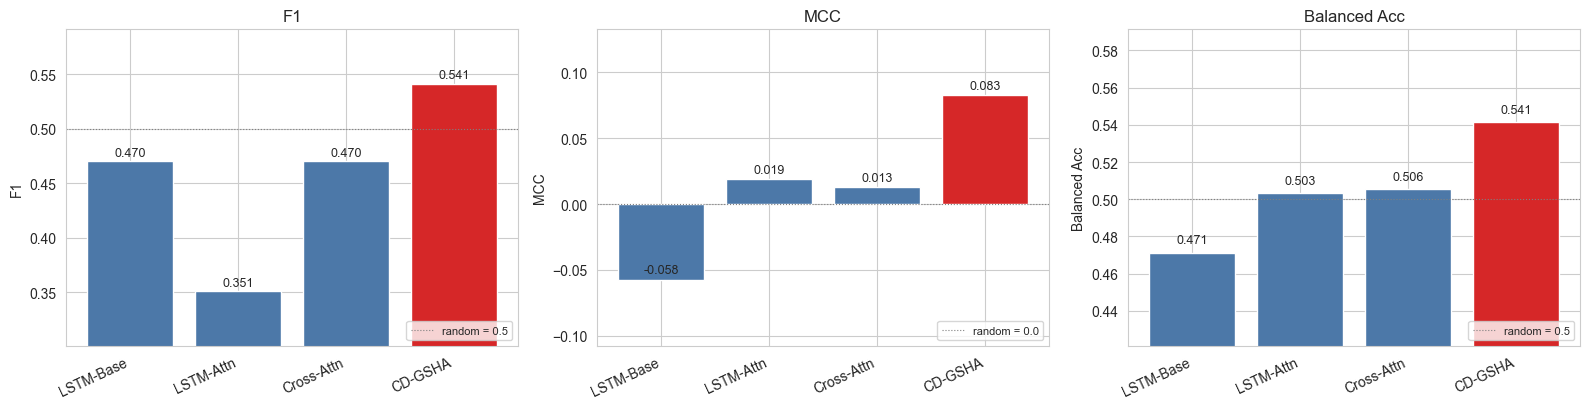

In [44]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
palette = {n: ('#d62728' if n == 'CD-GSHA' else '#4c78a8') for n in results_df.index}
for ax, metric, baseline in zip(axes, ['F1', 'MCC', 'Balanced Acc'], [0.5, 0.0, 0.5]):
    vals = results_df[metric].values
    names = results_df.index.tolist()
    colors = [palette[n] for n in names]
    bars = ax.bar(range(len(vals)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(names, rotation=25, ha='right')
    ax.axhline(baseline, ls=':', color='gray', lw=0.8, label=f'random = {baseline}')
    ax.set_ylabel(metric)
    lo = min(min(vals) - 0.05, baseline - 0.05); hi = max(max(vals) + 0.05, baseline + 0.05)
    ax.set_ylim(lo, hi)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                ha='center', fontsize=9)
    ax.legend(loc='lower right', fontsize=8); ax.set_title(metric)
plt.tight_layout(); plt.savefig('cdgsha_primary.png', dpi=150, bbox_inches='tight'); plt.show()


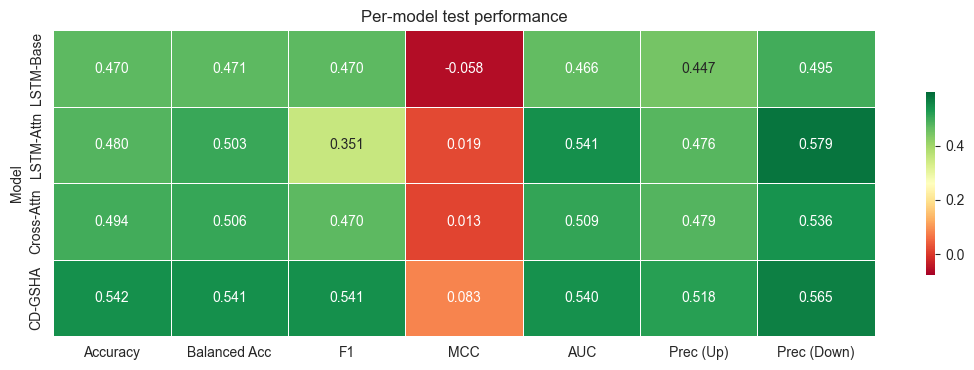

In [45]:
fig, ax = plt.subplots(figsize=(11, 3.8))
heat = results_df[['Accuracy', 'Balanced Acc', 'F1', 'MCC', 'AUC',
                   'Prec (Up)', 'Prec (Down)']].astype(float)
sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'shrink': 0.6}, ax=ax, linewidths=0.5, linecolor='white',
            vmin=heat.min().min() - 0.02, vmax=heat.max().max() + 0.02)
ax.set_title('Per-model test performance')
plt.tight_layout(); plt.savefig('cdgsha_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


---

## 15. Ablation Study

We isolate the contribution of each CD-GSHA component by disabling it and re-running the same training protocol.

| Variant | Modification |
|---|---|
| **CD-GSHA**                    | Reference (full architecture) |
| **CD-GSHA − temporal priors**  | $\beta_g$ frozen at 0 → semantic edges only |
| **CD-GSHA − graph**            | $\hat{\mathbf{L}}^{\text{dir}} = \mathbf{0}$ → ChebConv reduces to per-day linear projection |
| **CD-GSHA − hyperbolic**       | $\beta = 0$ frozen → pure Euclidean attention |
| **CD-GSHA − Euclidean**        | $\alpha = 0$ frozen → pure hyperbolic attention |
| **CD-GSHA − price causal**     | Replace price-side `CausalSelfAttention` with Identity |
| **CD-GSHA + symmetric graph**  | Use **symmetric** Laplacian, ignoring directionality (ablates the central novelty) |


In [46]:
class CDGSHA_NoTemporal(CDGSHA):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        with torch.no_grad():
            self.graph_builder.beta.data.fill_(0.0)
        self.graph_builder.beta.requires_grad_(False)


class CDGSHA_NoGraph(CDGSHA):
    '''L_dir set to zero in forward; ChebConv reduces to a per-day linear map.'''
    def forward(self, xn, xt, xm):
        if self.training and self.noise_std > 0:
            xn = xn + torch.randn_like(xn) * self.noise_std
        po, _ = self.price_lstm(xn)
        po    = self.price_causal(po)
        pctx  = self.price_proj(po[:, -1, :])
        B, T, _ = xt.shape
        L_zero  = torch.zeros(B, T, T, device=xt.device)
        Z = self.cheb_conv(xt, L_zero)
        c_hyp, _ = self.hyp_attn(pctx, Z)
        nd    = xm.mean(dim=1, keepdim=True)
        rho   = self.rho_gate(torch.cat([pctx, c_hyp, nd], dim=-1))
        fused = rho * c_hyp + (1 - rho) * pctx
        so, _ = self.sent_lstm(xn[:, :, -1:].contiguous())
        sctx  = self.sent_proj(so[:, -1, :])
        return self.classifier(torch.cat([fused, sctx], dim=-1)).squeeze(-1) + self.bias


class CDGSHA_NoHyperbolic(CDGSHA):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        with torch.no_grad():
            self.hyp_attn.log_beta.data.fill_(-20.0)
        self.hyp_attn.log_beta.requires_grad_(False)


class CDGSHA_NoEuclidean(CDGSHA):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        with torch.no_grad():
            self.hyp_attn.log_alpha.data.fill_(-20.0)
        self.hyp_attn.log_alpha.requires_grad_(False)


class CDGSHA_NoPriceCausal(CDGSHA):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.price_causal = nn.Identity()


class _SymmetricGraphBuilder(nn.Module):
    '''Symmetric replacement for the directional graph builder. Used only by
    the CDGSHA_SymmetricGraph ablation.'''
    def __init__(self, threshold_init=0.5, gamma_init=0.1):
        super().__init__()
        self.log_tau   = nn.Parameter(torch.tensor(threshold_init).log())
        self.log_gamma = nn.Parameter(torch.tensor(gamma_init).log())
        self.alpha     = nn.Parameter(torch.tensor(1.0))
        self.beta      = nn.Parameter(torch.tensor(0.3))
    def forward(self, x_text, x_mask):
        B, T, _ = x_text.shape
        device  = x_text.device
        tau   = torch.sigmoid(self.log_tau)
        nx    = F.normalize(x_text, dim=-1)
        sim   = torch.bmm(nx, nx.transpose(1, 2))
        A_sem = torch.sigmoid((sim - tau) * 10.0)
        m2    = x_mask.unsqueeze(2) * x_mask.unsqueeze(1)
        A_sem = A_sem * m2
        idx   = torch.arange(T, device=device, dtype=torch.float32)
        dist  = (idx.unsqueeze(0) - idx.unsqueeze(1)).abs()
        gamma = torch.exp(self.log_gamma)
        A_tmp = torch.exp(-gamma * dist).unsqueeze(0).expand(B, -1, -1)
        A = self.alpha.abs() * A_sem + self.beta.abs() * A_tmp
        I = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        A = A * (1 - I)  # remove self-loops
        deg = A.sum(-1).clamp(min=EPS)
        Di  = (deg ** -0.5).unsqueeze(-1)
        L_sym = Di * A * Di.transpose(1, 2)   # symmetric normalisation
        return L_sym, A


class CDGSHA_SymmetricGraph(CDGSHA):
    '''Replaces the causal directional graph with a symmetric one. This
    re-introduces the future-to-past leakage that CD-GSHA was designed to
    eliminate, and is the most important ablation: it isolates the value
    of directionality in the graph.
    '''
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.graph_builder = _SymmetricGraphBuilder()


In [47]:
ABLATION_CLASSES = {
    'CD-GSHA':                    CDGSHA,
    'CD-GSHA - temporal priors':  CDGSHA_NoTemporal,
    'CD-GSHA - graph':            CDGSHA_NoGraph,
    'CD-GSHA - hyperbolic part':  CDGSHA_NoHyperbolic,
    'CD-GSHA - euclidean part':   CDGSHA_NoEuclidean,
    'CD-GSHA - price causal':     CDGSHA_NoPriceCausal,
    'CD-GSHA + symmetric graph':  CDGSHA_SymmetricGraph,
}

print('Ablation study — same protocol, architecture varies.\n')
ablation_results = {}
for name, cls in ABLATION_CLASSES.items():
    print(f'-- {name} --')
    ablation_results[name] = run_experiment(cls, name, verbose=False)
    r = ablation_results[name]
    print(f'  test_F1={r["f1"]:.4f}  test_MCC={r["mcc"]:.4f}  '
          f'test_BalAcc={r["balanced_acc"]:.4f}  AUC={r["auc"]:.4f}\n')

ablation_df = pd.DataFrame([_row(n, r) for n, r in ablation_results.items()]).set_index('Model')
ref = ablation_df.loc['CD-GSHA']
ablation_df['d Accuracy'] = ablation_df['Accuracy']     - ref['Accuracy']
ablation_df['d F1']       = ablation_df['F1']           - ref['F1']
ablation_df['d MCC']      = ablation_df['MCC']          - ref['MCC']
ablation_df['d BalAcc']   = ablation_df['Balanced Acc'] - ref['Balanced Acc']

print('=' * 100)
print('                                 ABLATION RESULTS')
print('=' * 100)
print(ablation_df[['Accuracy', 'F1', 'MCC', 'Balanced Acc', 'AUC',
                   'd Accuracy', 'd F1', 'd MCC', 'd BalAcc']].to_string(
      float_format=lambda v: f'{v:+.4f}' if abs(v) < 0.1 else f'{v:.4f}'))


Ablation study — same protocol, architecture varies.

-- CD-GSHA --
  test_F1=0.5414  test_MCC=0.0827  test_BalAcc=0.5414  AUC=0.5404

-- CD-GSHA - temporal priors --
  test_F1=0.4498  test_MCC=0.0384  test_BalAcc=0.5147  AUC=0.5367

-- CD-GSHA - graph --
  test_F1=0.3711  test_MCC=0.0149  test_BalAcc=0.5035  AUC=0.5254

-- CD-GSHA - hyperbolic part --
  test_F1=0.5263  test_MCC=0.0594  test_BalAcc=0.5296  AUC=0.5361

-- CD-GSHA - euclidean part --
  test_F1=0.5417  test_MCC=0.0836  test_BalAcc=0.5418  AUC=0.5390

-- CD-GSHA - price causal --
  test_F1=0.4934  test_MCC=0.0221  test_BalAcc=0.5101  AUC=0.5319

-- CD-GSHA + symmetric graph --
  test_F1=0.4365  test_MCC=-0.0263  test_BalAcc=0.4892  AUC=0.4877

                                 ABLATION RESULTS
                           Accuracy     F1     MCC  Balanced Acc    AUC  d Accuracy    d F1   d MCC  d BalAcc
Model                                                                                                        
CD-GSHA       

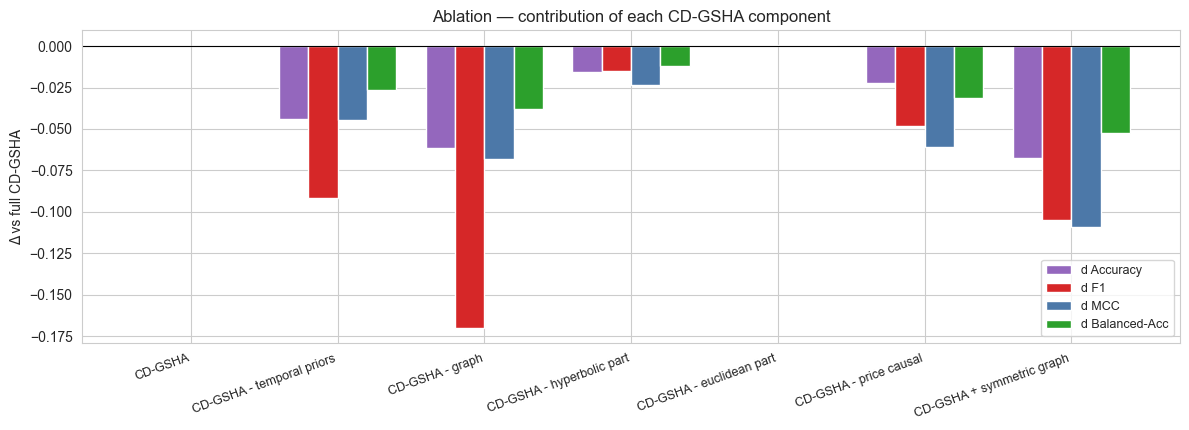

In [48]:
fig, ax = plt.subplots(figsize=(12, 4.4))
x = np.arange(len(ablation_df)); width = 0.20
b1 = ax.bar(x - 1.5*width, ablation_df['d Accuracy'], width, color='#9467bd', label='d Accuracy')
b2 = ax.bar(x - 0.5*width, ablation_df['d F1'],       width, color='#d62728', label='d F1')
b3 = ax.bar(x + 0.5*width, ablation_df['d MCC'],      width, color='#4c78a8', label='d MCC')
b4 = ax.bar(x + 1.5*width, ablation_df['d BalAcc'],   width, color='#2ca02c', label='d Balanced-Acc')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ablation_df.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Δ vs full CD-GSHA')
ax.set_title('Ablation — contribution of each CD-GSHA component')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('cdgsha_ablation.png', dpi=150, bbox_inches='tight'); plt.show()


---

## 16. Discussion

The ablation **CD-GSHA + symmetric graph** is the central test of the architectural hypothesis. If the directional graph is genuinely contributing, replacing it with a symmetric graph (which lets future news bleed into past representations through Chebyshev propagation) should hurt performance. If the directional graph is not contributing, performance should be similar — in which case the simpler symmetric architecture is preferable. Either outcome is informative.

The remaining ablations check that the supporting components — temporal priors, hyperbolic correction, Euclidean term, price-side causal attention — each pull their weight on this dataset.

### What CD-GSHA does differently from the literature

- **Defferrard et al. (2016)** (ChebConv) and **Veličković et al. (2018)** (GAT) operate on symmetric graphs. We extend the spectral approach to a strictly directional graph using random-walk normalization.
- **Nickel & Kiela (2017)** introduced Poincaré embeddings. We use this geometry as a learnable correction term inside attention rather than as a complete replacement, addressing the boundary instability of pure-hyperbolic attention.
- The cross-modal confidence gate conditioned on news density is, to our knowledge, novel for this task.

### Limitations

- Single commodity, single forecast horizon (next-day).
- 16-D FinBERT embedding is low-capacity.
- The graph is constructed per-window; a global news graph across the whole training set might capture longer-range thematic structure.
